In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations
from collections import defaultdict

from xgboost import XGBClassifier
from sklearn.model_selection import BaseCrossValidator, ParameterGrid
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
import joblib

In [4]:
# Import data:
# run script from the data_input file
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df = pd.read_csv("data_final.csv", parse_dates=['Date'])
df = df.set_index('Date')


data = pd.concat([df,df_factor], axis=1, join='inner')
data = data.dropna()

print(data)

            OEZAKLAF_YoY  momentum_value_vol_ratio  momentum_ret_lag4  \
Date                                                                    
2007-01-29        0.7703                  1.123636           0.000357   
2007-02-05        0.7703                  1.123636           0.000357   
2007-02-12        0.7703                  1.123636           0.000357   
2007-02-19        0.7703                  1.123636           0.000357   
2007-02-26        0.7703                  1.123636           0.000357   
...                  ...                       ...                ...   
2023-12-04       -1.1947                  0.898066           0.005728   
2023-12-11       -1.1947                  0.920047          -0.041804   
2023-12-18       -1.1947                  0.925637           0.003492   
2023-12-25       -1.1947                  0.954099           0.071402   
2024-01-01       -1.1848                  0.953191           0.000900   

            LA1StructBreak  USNomBndStructBreak_Le

In [5]:
# ========================
# Phase 1: Combinatorial Purged CV
# ========================
CV_SPLITS = 5
CV_TEST_SPLITS = 1
PURGE_GAP = 24
FINAL_TEST_POINTS = 156   # 3 years of unseen data

class CombinatorialPurgedCV(BaseCrossValidator):
    """Purged Combinatorial Cross-Validation (De Prado style)."""
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None): 
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)

        # Create fold boundaries
        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)

        # Generate test fold combinations
        for test_fold_indices in combinations(range(self.n_splits), self.n_test_splits):
            test_mask = np.zeros(n_samples, dtype=bool)

            # Collect test indices
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]
                test_mask[start:end] = True

            # Train mask is everything else
            train_mask = ~test_mask

            # Purge around each test fold
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]

                # purge before
                train_mask[max(0, start - self.purge_gap): start] = False
                # purge after
                train_mask[end: min(n_samples, end + self.purge_gap)] = False

            yield indices[train_mask], indices[test_mask]
    
    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)


def tune_hyperparameters(X, y):
    """Grid search over CPCV folds."""
    cv = CombinatorialPurgedCV()

    param_grid = {
        'learning_rate': [0.01, 0.5, 1],
        'max_depth': [3, 8, 16, 32],
        'subsample': [0.4, 0.7, 1.0],
       # 'colsample_bytree': [0.4, 0.7, 1.0],
        'base_score': [0.5,0.6,0.65,0.7]
    }

    best_score, best_params = -np.inf, None
    results = []

    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):
        model = XGBClassifier(objective='binary:logistic',
                              eval_metric='logloss',
                              n_estimators=1000,
                              **params)
        
        fold_scores = []
        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train, verbose=False)
            score = roc_auc_score(y_test, model.predict(X_test))
            fold_scores.append(score)
        
        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))

        if mean_score > best_score:
            best_score, best_params = mean_score, params
            print(f"New best params: {best_params} (accuracy: {best_score:.3f})")
    
    # Report top 5
    results.sort(key=lambda x: x[1], reverse=True)
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")
    
    return best_params



In [6]:
# ========================
# Phase 2: Walk-Forward Validation
# ========================
def walk_forward_validation(X, y, n_test, base_params, retune_every=None):

    actuals, predictions, probabilities = [], [], []
    current_params = base_params.copy()
    
    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")
    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue
        
        X_train, X_test = X[:train_size], X[train_size:train_size+1]
        y_train, y_test = y[:train_size], y[train_size:train_size+1]
        
        # Re-tune hyperparameters
        if retune_every is not None and i > 0 and i % retune_every == 0:
            print(f"\n--- Retuning at step {i}, train_size={train_size} ---")
            current_params = tune_hyperparameters(X_train, y_train)
        
        # Fit model
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=1000,
            **current_params
        )
        model.fit(X_train, y_train, verbose=False)
        
        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])
    
    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))
    
    return np.array(actuals), np.array(predictions), np.array(probabilities)



In [7]:
# ========================
# Phase 3: Plotting
# ========================
def plot_wfv_results(actuals, predictions, probabilities):
    auc = roc_auc_score(actuals, probabilities)
    avg_prec = average_precision_score(actuals, probabilities)

    print(f"ROC AUC: {auc:.3f}")
    print(f"Average Precision (PR AUC): {avg_prec:.3f}")

    # Timeline plot
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='Actual', marker='o')
    plt.plot(predictions, label='Predicted', marker='x')
    plt.plot(probabilities, label='Probability', linestyle='--', alpha=0.5)
    plt.title('Walk-Forward Validation Results')
    plt.legend()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(actuals, probabilities)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(actuals, probabilities)
    plt.figure(figsize=(6, 6))
    plt.plot(rec, prec, label=f'PR Curve (AP = {avg_prec:.3f})', color='purple')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # Confusion Matrix
    cm = confusion_matrix(actuals, predictions)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()



=== PHASE 1: HYPERPARAMETER TUNING ===
Testing 144 parameter combinations...
New best params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4} (accuracy: 0.564)
New best params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4} (accuracy: 0.566)

=== Top 5 Parameter Combinations ===
Score: 0.566 | Params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4}
Score: 0.564 | Params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4}
Score: 0.563 | Params: {'base_score': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4}
Score: 0.561 | Params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}
Score: 0.561 | Params: {'base_score': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}

=== PHASE 2: FINAL EVALUATION ===

Running Walk-Forward Validation on 156 test samples...


100%|██████████| 156/156 [03:13<00:00,  1.24s/it]



=== Final Evaluation Results ===
              precision    recall  f1-score   support

         0.0       0.64      0.74      0.68        76
         1.0       0.71      0.60      0.65        80

    accuracy                           0.67       156
   macro avg       0.67      0.67      0.67       156
weighted avg       0.67      0.67      0.67       156


Running Walk-Forward Validation on 156 test samples...


 33%|███▎      | 52/156 [00:52<01:39,  1.04it/s]


--- Retuning at step 52, train_size=772 ---
Testing 144 parameter combinations...
New best params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4} (accuracy: 0.596)
New best params: {'base_score': 0.5, 'learning_rate': 0.5, 'max_depth': 3, 'subsample': 0.7} (accuracy: 0.602)
New best params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7} (accuracy: 0.603)

=== Top 5 Parameter Combinations ===
Score: 0.603 | Params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}
Score: 0.602 | Params: {'base_score': 0.5, 'learning_rate': 0.5, 'max_depth': 3, 'subsample': 0.7}
Score: 0.602 | Params: {'base_score': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4}
Score: 0.601 | Params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4}
Score: 0.601 | Params: {'base_score': 0.65, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}


 67%|██████▋   | 104/156 [15:38<00:44,  1.16it/s]  


--- Retuning at step 104, train_size=824 ---
Testing 144 parameter combinations...
New best params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4} (accuracy: 0.591)
New best params: {'base_score': 0.65, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7} (accuracy: 0.591)
New best params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4} (accuracy: 0.593)

=== Top 5 Parameter Combinations ===
Score: 0.593 | Params: {'base_score': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4}
Score: 0.591 | Params: {'base_score': 0.65, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}
Score: 0.591 | Params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.4}
Score: 0.591 | Params: {'base_score': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}
Score: 0.590 | Params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.7}


100%|██████████| 156/156 [30:59<00:00, 11.92s/it]   



=== Final Evaluation Results ===
              precision    recall  f1-score   support

         0.0       0.63      0.78      0.70        76
         1.0       0.73      0.57      0.64        80

    accuracy                           0.67       156
   macro avg       0.68      0.68      0.67       156
weighted avg       0.68      0.67      0.67       156


=== Fixed Params ===
ROC AUC: 0.698
Average Precision (PR AUC): 0.676


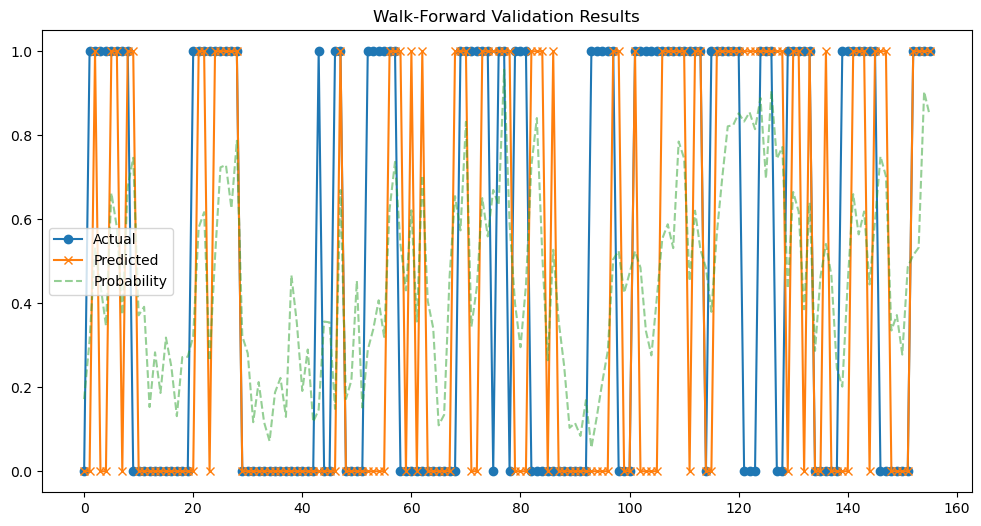

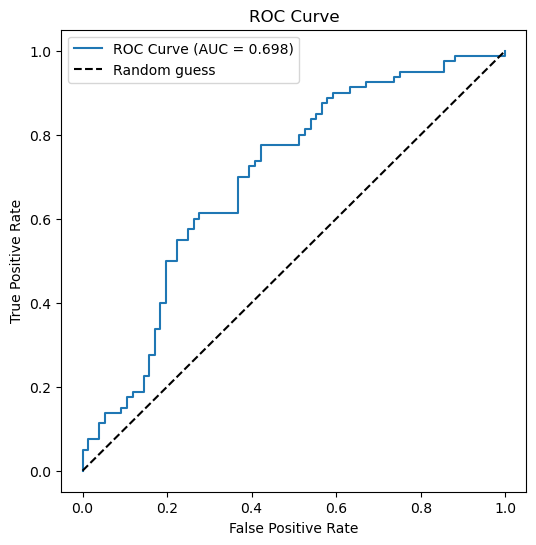

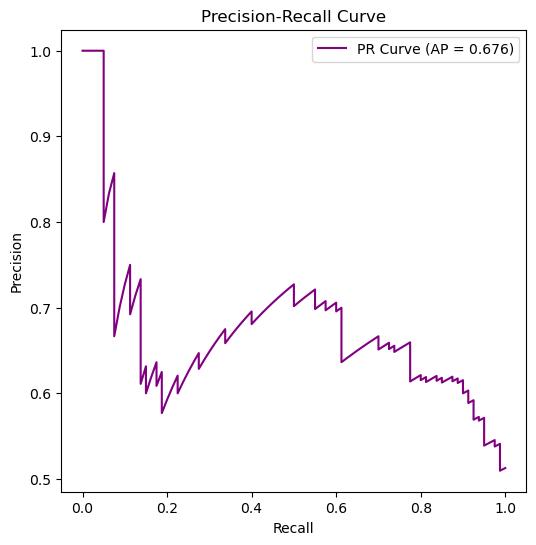

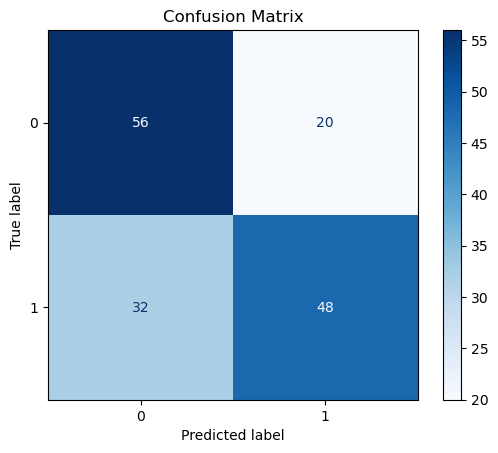


=== Adaptive Params ===
ROC AUC: 0.714
Average Precision (PR AUC): 0.689


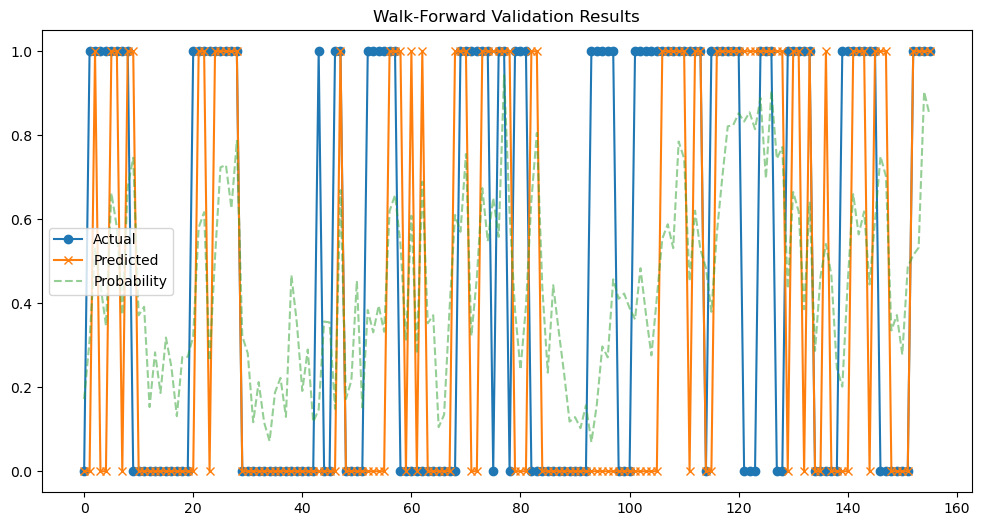

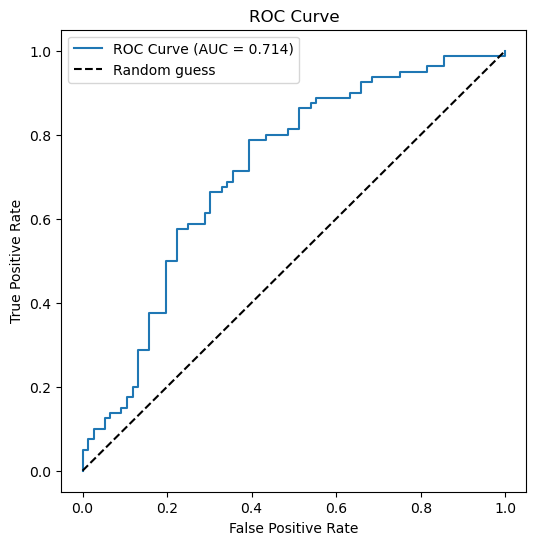

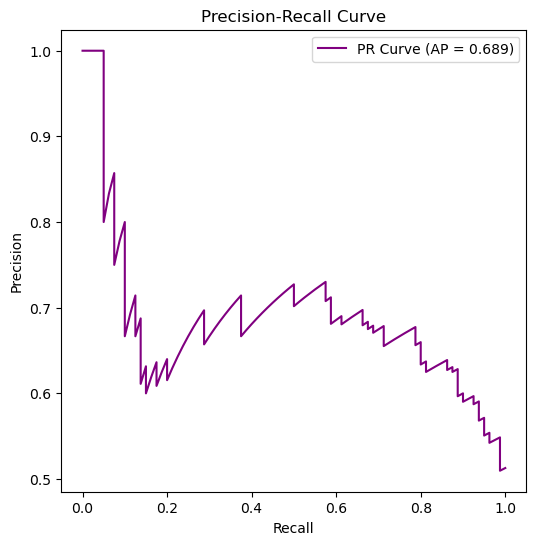

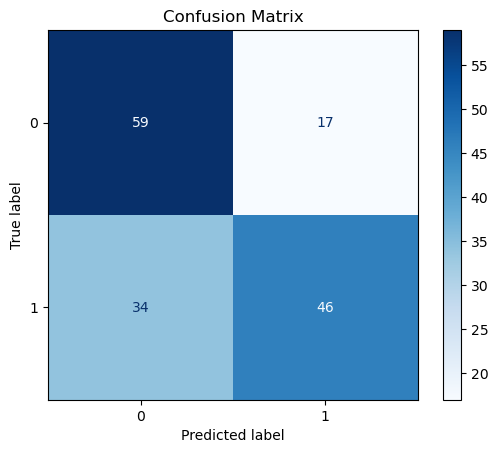

In [ ]:
# ========================
# Main Entry Point
# ========================

# Data import:

def main():
    # Prepare data
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

    # Phase 1: Tune hyperparameters once on training set 
    # parameters used for fixed parameters
    # initial tuning for addptive parameters
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X, y)

    # Phase 2: Walk-forward evaluation
    print("\n=== PHASE 2: FINAL EVALUATION ===")

    # Fixed params - no tunning set retune_every=None
    actuals, preds, probs = walk_forward_validation(
        X, y, FINAL_TEST_POINTS, best_params, retune_every=None
    )

    # Adaptive params - set months using retune_every=n
    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(
        X, y, FINAL_TEST_POINTS, best_params, retune_every=52
    )

    # Phase 3: Plots
    print("\n=== Fixed Params ===")
    plot_wfv_results(actuals, preds, probs)

    print("\n=== Adaptive Params ===")
    plot_wfv_results(actuals_adapt, preds_adapt, probs_adapt)

    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "fixed": (actuals, preds, probs),
        "adaptive": (actuals_adapt, preds_adapt, probs_adapt),
    }


if __name__ == "__main__":
    results = main()
    